# Trajectory Explanatory Analysis v2

Notebook ini otomatis memilih job lengkap terbaru, melakukan QC dan analytics lanjut, lalu menerbitkan package `explanatory-v2`. Set `FOODCOURT_JOB_ID` sebelum membuka Jupyter jika ingin memilih job tertentu.

Heatmap menggunakan density kontinu berbobot waktu, bukan histogram point-count. Koordinat floorplan memakai x ke kanan dan y ke bawah.


,jobId,completedMtime,venue,widthM,heightM,totalVisitors,globalIds,trajectoryAvailable
0,72ebb6668052,1.786414e+09,(tanpa nama),10.0,7.5,41,41,True
1,111e6eb341cb,1.786344e+09,pujasera,10.0,7.5,17,17,True
2,8da50be884da,1.786343e+09,(tanpa nama),10.0,7.5,32,32,True


## Package aktif

`/Users/daf2a/Documents/Challenge/c2/be/path-simulation/notebooks/output/72ebb6668052/explanatory-v2`

,rawObservationCount,validObservationCount,validPointRatio,outOfVenueCount,nonFiniteCount,duplicateCount,speedAnomalyCount,estimatedSamplingFps,calibrationWarnings,binSeconds,...,presenceAreaCount,crowdAreaCount,flowAreaCount,bottleneckAreaCount,routeArchetypeCount,groupEpisodeCount,soloObservationRatio,maxObservedGroupSize,annotationAvailable,tableCount
quality,29026.0,25373.0,0.874147,3653.0,0.0,0.0,88.0,5.003268,[],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupancy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dwell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
movement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.0,3.0,5.0,0.0,3.0,NaN,NaN,NaN,NaN,NaN
groups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,0.993708,2.0,NaN,NaN
tables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0


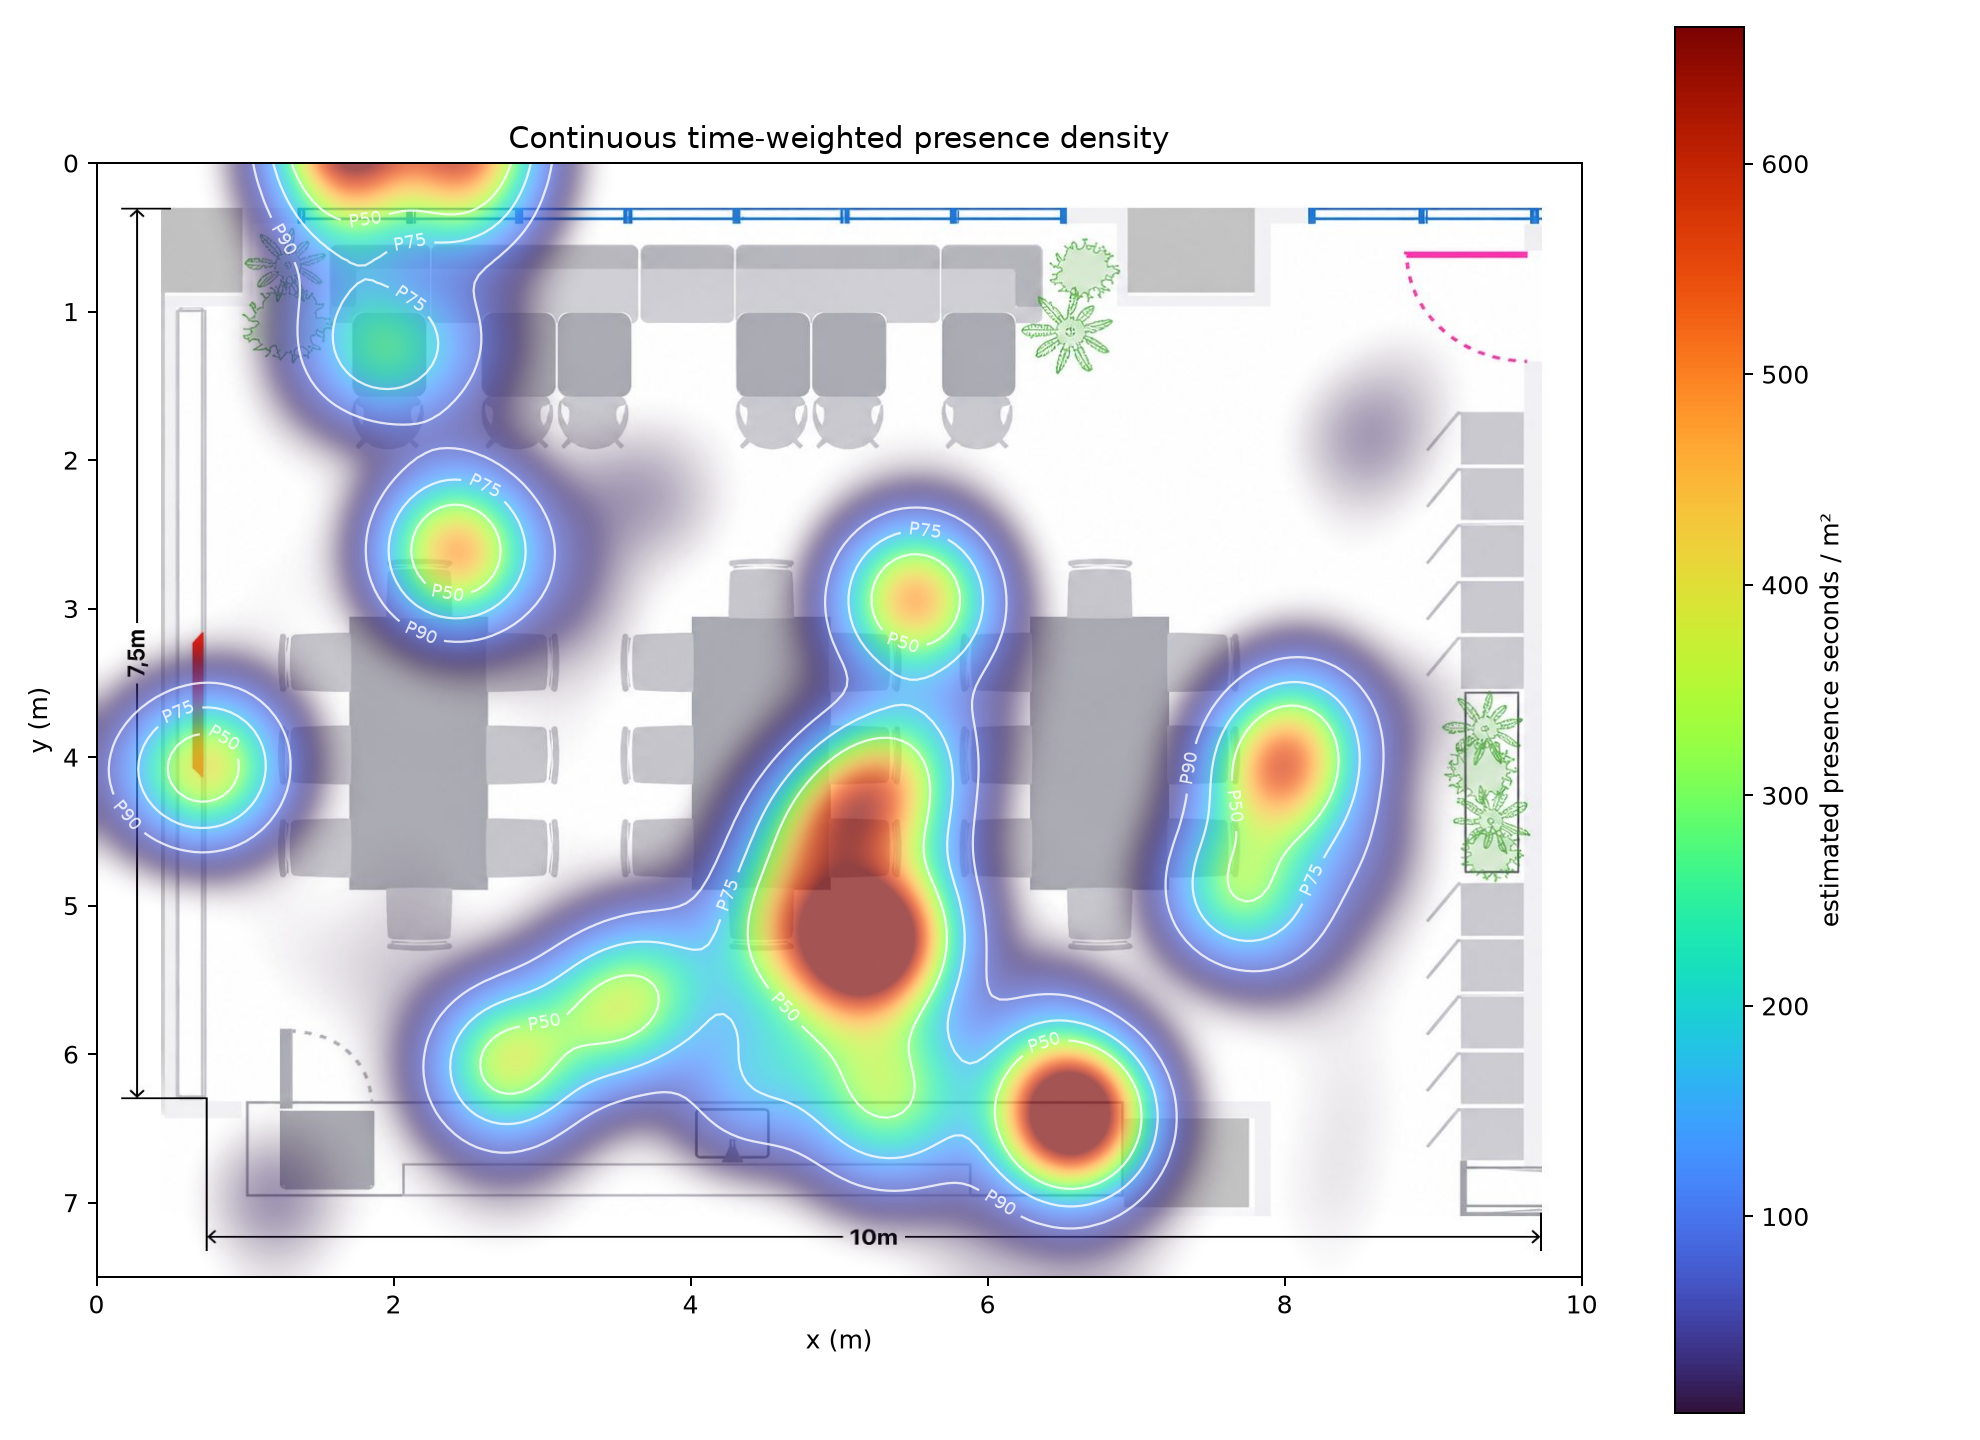

In [1]:
%matplotlib widget
from pathlib import Path
import sys

BACKEND_ROOT = next(candidate for candidate in (Path.cwd(), Path.cwd().parent) if (candidate / 'explanatory_analysis').is_dir())
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display

from explanatory_analysis import AnalysisConfig, discover_jobs, run_analysis

config = AnalysisConfig.default()
display(discover_jobs(config.workdir))
analysis_result = run_analysis(config)
display(Markdown(f"## Package aktif\n\n`{analysis_result.output_dir}`"))
display(pd.DataFrame([analysis_result.summary[section] for section in ["quality", "occupancy", "dwell", "movement", "groups", "tables"]], index=["quality", "occupancy", "dwell", "movement", "groups", "tables"]))
display(Image(filename=str(analysis_result.output_dir / "figures" / "floorplan_presence_density.png")))


## Annotation meja opsional

Gunakan canvas yang **embedded di notebook**: klik langsung pada floorplan untuk menambah setiap titik sudut meja. Setelah minimal tiga titik, beri label dan tekan **Tambah meja**; polygon ditutup otomatis. Tekan **Simpan & rebuild** setelah semua meja selesai. Tanpa annotation, seluruh analytics non-meja tetap tersedia. Annotation hanya perlu dilakukan sekali untuk setiap venue fingerprint.


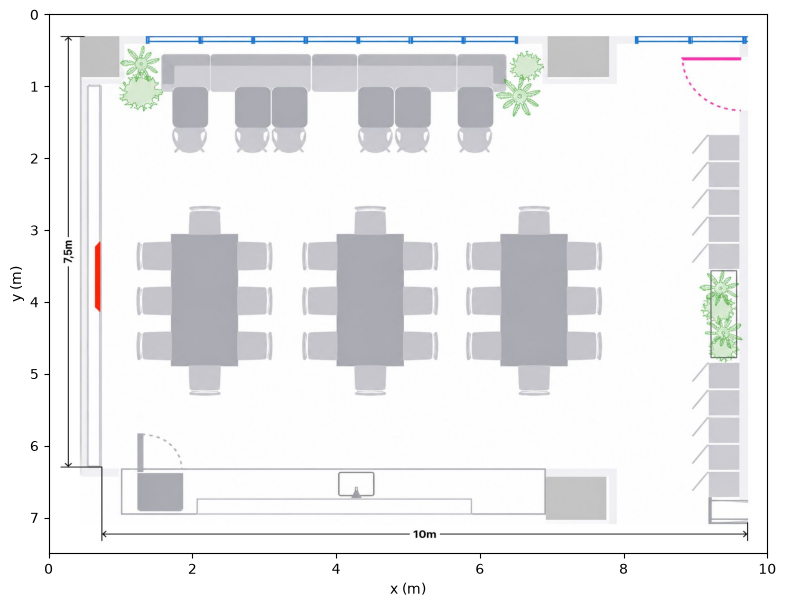

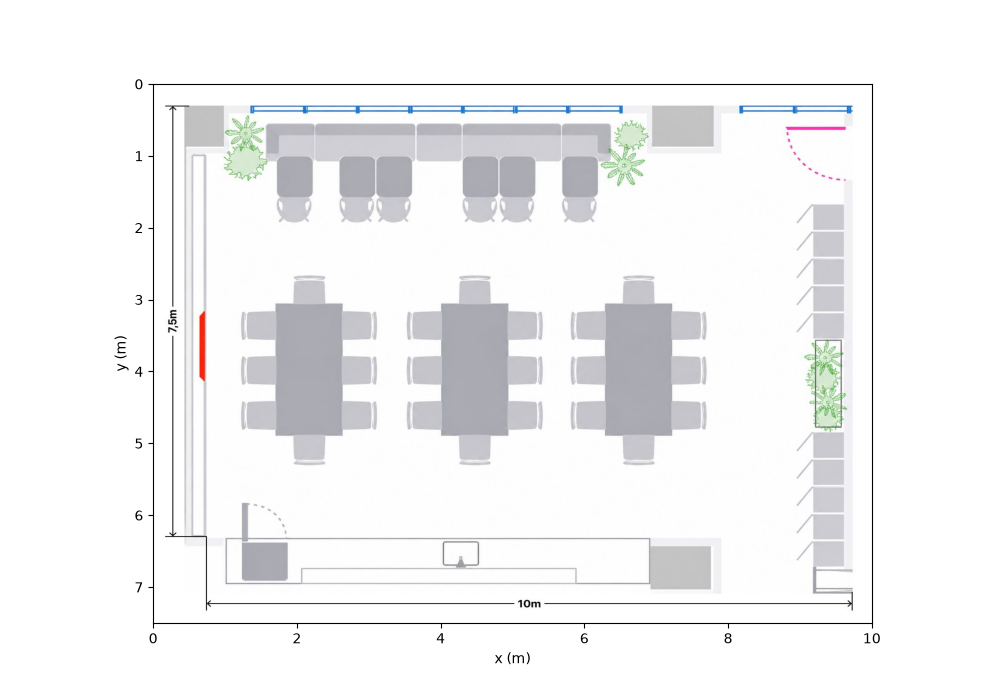

In [2]:
import os
from explanatory_analysis import create_table_annotation_widget

if os.environ.get('FOODCOURT_HEADLESS') == '1':
    print('Annotation widget dilewati pada eksekusi headless/nbconvert.')
else:
    table_annotation_controls = create_table_annotation_widget(analysis_result)
    display(table_annotation_controls)


In [3]:
import json

manifest = json.loads((analysis_result.output_dir / "manifest.json").read_text())
missing = [name for name in manifest["files"] if not (analysis_result.output_dir / name).exists()]
assert not missing, missing
assert manifest["schemaVersion"] == "2.0"
assert manifest["coordinateSystem"]["orientation"] == "x_right_y_down"
print(f"Valid: {len(manifest['files'])} artefak; latest pointer siap untuk notebook LLM.")


Valid: 24 artefak; latest pointer siap untuk notebook LLM.
